# SUPER 2026 Starting Demo

Hi! This notebook is meant to demonstrate the SpiralTorch lidar processing library, to which you will be contributing. We would like to expand the tools in this repo, so that the solver smartly chooses the optimizer based on the form of the parameter to be retrieved. 

Specifically, the Spiral method is well suited for finding the 2D solution which minimizes the Poission Negative Log-Likelihood (NLL) constrained with a total variation (TV) term. This (NLL + TV) is the objective function for the Spiral estimation problem. In many atmospheric lidar use cases, it is necessary to estimate 1D or scalar parameters. This is exemplified by the HSRL (High-Spectral Resolution Lidar) systems operated at NCAR. HSRL is a lidar technique which allows for the calculation of a calibrated backscatter coefficient for airborne scatterers (cloud/aerosol). This is achieved by taking a ratio of two channels, one of which has been filtered so that it only contains signal from clear air. Scalar values representing the gain of the channels and their sensitivities to aerosol/molecular signal directly impact the accuracy of the retrieved backscatter coefficient result. However, the Spiral optimizer is not appropriate for the estimation of these scalars since the TV term is not applicable for a scalar. Therefore, other, more efficient approaches to this problem, such as gradient descent, should be explored.

# Notebook Setup

Configure environment, import SpiralTorch, vand verify cuda/PyTorch

Test and demonstrate functionality from `spiral.py`

In [1]:
import sys, os, importlib
import torch
import numpy as np
import matplotlib.pyplot as plt
import yaml
import time

Load in a path config file that Matt and I keep in our home directories. Alternatively, manually set the path to SpiralTorch

In [2]:
# load file path information from the home directory
file_path_yml = os.path.join(os.environ["HOME"], ".ncar_config_derecho.yaml")
path_data = {}
with open(file_path_yml, "r") as r:
    path_data = yaml.safe_load(r)

dirP_str = os.path.join(path_data["ptv_collection_path"], "SpiralTorch", "python")
dirP_str = '/glade/u/home/bgarby/projects/SpiralTorch/python' # Manually set the path...
if dirP_str not in sys.path:
    sys.path.append(dirP_str)

In [3]:
from SpiralTorch import spiral
from SpiralTorch import loss
from SpiralTorch import fista
#os.environ['PYTHONPATH'] # This is legacy from Matt's environment, don't think it's needed

SpiralTorch custom cuda kernel for FISTA. Should work if environment was set up right.

In [4]:
import STCuda

Check the PyTorch environment. See if cuda is working and if a GPU is detected.

In [5]:
is_cuda = torch.cuda.is_available()
device = torch.device(torch.cuda.current_device()) if is_cuda else torch.device("cpu")
# device = torch.device("cpu")

if is_cuda:
    torch.backends.cudnn.benchmark = True

print(f'Preparing to use device {device}')
print(f"Current device name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
print(f'Torch version: {torch.__version__}')

dtype = torch.float64 # Consider changing to float32...

Preparing to use device cuda:0
Current device name: Tesla V100-SXM2-32GB
Torch version: 2.8.0+cu129


# Single variable Spiral Poisson Noise
To start we will look at the basic SpiralTorch functionality. We will create and process Poisson noisy images

### Generate some data to denoise

In [6]:
x_axis = np.linspace(-10,10,64)
y_axis = np.linspace(-10,10,128)
x_ax_mesh,y_ax_mesh = np.meshgrid(x_axis,y_axis)

rec_count = 80

# uniform distribution
# rec_x_position_arr = 20*(np.random.rand(rec_count)-0.5)
# rec_y_position_arr = 20*(np.random.rand(rec_count)-0.5)
# normal distribution
rec_x_position_arr = 5*(np.random.randn(rec_count))
rec_y_position_arr = 5*(np.random.randn(rec_count))
rec_x_arr = np.random.randn(rec_count)*5
rec_y_arr = np.random.randn(rec_count)*5
alpha_rec_arr = 20*np.random.rand(rec_count)

alpha_arr = np.zeros((y_axis.size,x_axis.size))

for idx in range(rec_count):
    rec_idx = np.where((y_ax_mesh >= rec_y_position_arr[idx]-rec_y_arr[idx]/2) & (y_ax_mesh <= rec_y_position_arr[idx]+rec_y_arr[idx]/2) & \
             (x_ax_mesh >= rec_x_position_arr[idx]-rec_x_arr[idx]/2) & (x_ax_mesh <= rec_x_position_arr[idx]+rec_x_arr[idx]/2))
    alpha_arr[rec_idx]+=alpha_rec_arr[idx]

alpha_arr+= 4

In [7]:
# create fit and validation data for the scene
y_obs_fit = np.random.poisson(alpha_arr)
y_obs_val = np.random.poisson(alpha_arr)

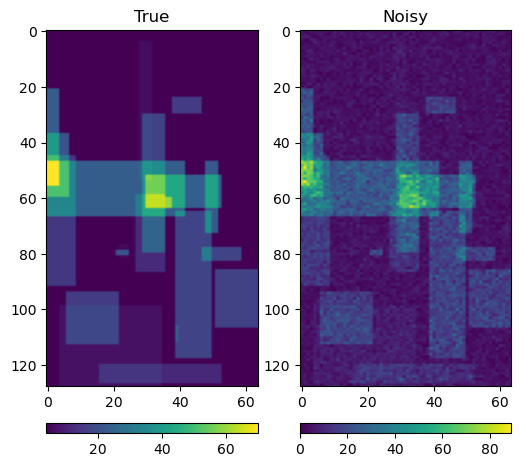

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(6, 6))

# Plot the first image on the left (index 0)
im0 = ax[0].imshow(alpha_arr, aspect='auto')
ax[0].set_title("True")
fig.colorbar(im0, ax=ax[0], orientation='horizontal', pad=0.08)

# Plot the second image on the right (index 1)
im1 = ax[1].imshow(y_obs_fit, aspect='auto')
ax[1].set_title("Noisy")
fig.colorbar(im1, ax=ax[1], orientation='horizontal', pad=0.08)

### Example of single Sparsa subproblem
Basic one-off setup for single sparse instance

In [9]:
fista_ver_str = 'cuda-fista'  # 'cuda-fista' for custom fista kernel, 'jit-fista' for kernel in pytorch
max_iter = 2000
loss_fnc = loss.pois_loss_fn

The forward model function accepts the estimated state variable `x` (dict) and outputs a dictionary `y` of the observation noise models.  In the simplest form, this is just the mean of the PDF (such as with Poisson noise).  However this can be applied to any PDF which may have multiple parameters.

The noise model output dict needs to match with the expected forward model kwargs in the loss function. See the loss.py file in the SpiralTorch repo for specifics on different noise models. For most, the kwarg "y_mean_est" is required.

In [10]:
def fwd_model_photons(**x):
    # really simple direct forward model
    return {'y_mean_est':torch.exp(x['backscatter'])+1e-20}

Similar to the forward model, the observations for each channel need to align with the expected observation kwargs in the loss function definition.  In the case of the Poisson noise model, it expects `counts` (for photon counts in a bin) and `shot_count` for the number of laser shots in a bin.

In [11]:
y_obs_dct_lst = [
    {'counts':torch.tensor(y_obs_fit,dtype=dtype,device=device),
    'shot_count':torch.ones((y_obs_fit.shape[0],1),dtype=dtype,device=device)},
]
fwd_model_lst = [fwd_model_photons]

The estimated state variable `x` can consist of multiple terms which have various relationships to each observed channel.  The entries for the state variable need to align with the expected kwargs in the forward model functions or methods.

In [12]:
x0 = {'backscatter':torch.zeros(y_obs_fit.shape,dtype=dtype,device=device)}

In [13]:
subprob = spiral.sparsa_torch_autograd(device,dtype) # Spiral optimization class
subprob.load_fit_parameters(x0,
                            y_obs_dct_lst,
                            fwd_model_lst,
                            'backscatter')
subprob.set_loss_fn_lst([loss_fnc])
subprob.set_fista(fista_ver_str)
subprob.set_penalty_weight(2.0e0)
subprob.set_max_iter(max_iter)
subprob.set_alpha_min(1e3)  # this is pretty key to establishing stability in the processing.  1 is too small.
# subprob.alpha
# subprob.set_alpha(1e8)

In [14]:
start_time = time.time()
result_str = subprob.solve_sparsa_subprob()
end_time = time.time()
print(fista_ver_str)
print(result_str)
print(f"Run duration: {end_time-start_time} seconds")

cuda-fista
Found Minimum for eps 1e-05. Final step: 9.969117292078137e-06
Run duration: 6.064086437225342 seconds


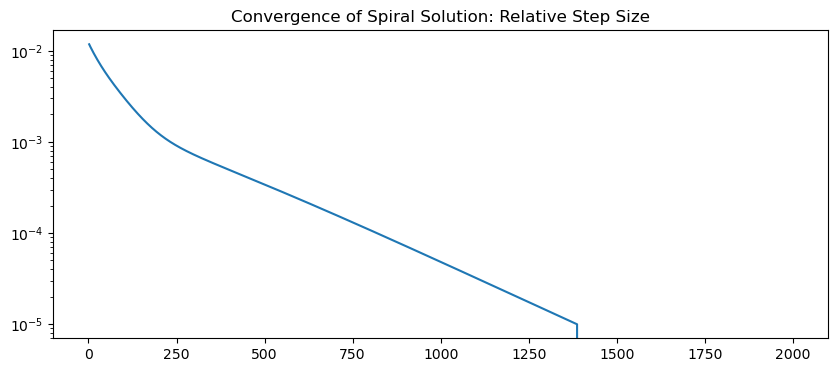

In [15]:
plt.figure(figsize=(10,4))
plt.title('Convergence of Spiral Solution: Relative Step Size')
plt.plot(subprob.rel_step_tnsr.detach().cpu().numpy())
plt.yscale('log')

Extract the estimated solution (in the 'x' basis)

In [16]:
x_est_arr = subprob.x.cpu().detach().numpy()
y_mean_est_soln = fwd_model_photons(**{'backscatter': subprob.x})
y_mean_est_arr = y_mean_est_soln['y_mean_est'].detach().cpu().numpy()

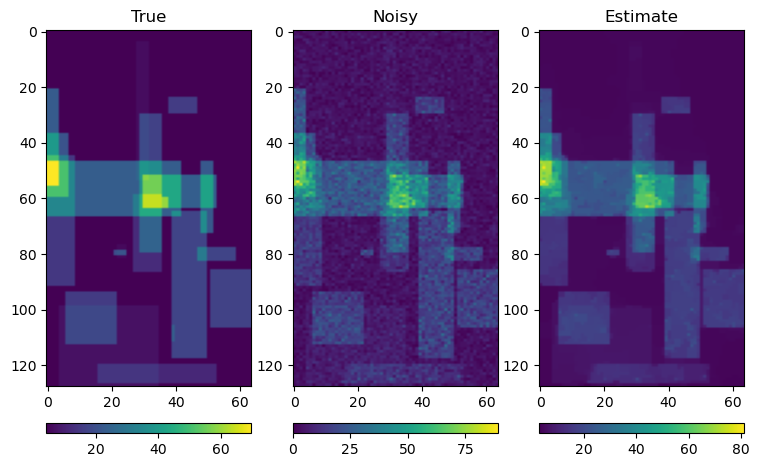

In [44]:
fig, ax = plt.subplots(1, 3, figsize=(9, 6))

im0 = ax[0].imshow(alpha_arr, aspect='auto')
ax[0].set_title("True")
fig.colorbar(im0, ax=ax[0], orientation='horizontal', pad=0.08)

im1 = ax[1].imshow(y_obs_fit, aspect='auto')
ax[1].set_title("Noisy")
fig.colorbar(im1, ax=ax[1], orientation='horizontal', pad=0.08)

im2 = ax[2].imshow(y_mean_est_arr, aspect='auto')
ax[2].set_title("Estimate")
fig.colorbar(im2, ax=ax[2], orientation='horizontal', pad=0.08)

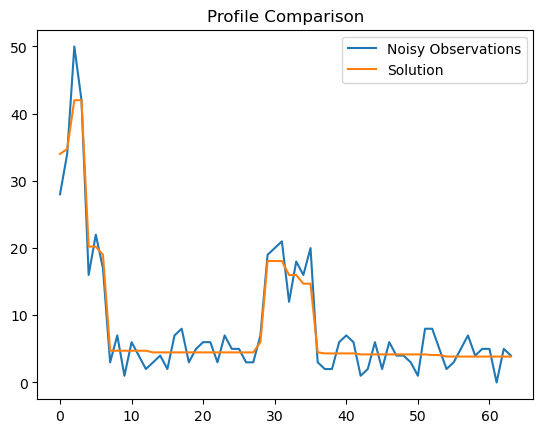

In [18]:
profile_index=40
plt.figure()
plt.title('Profile Comparison')
plt.plot(y_obs_dct_lst[0]['counts'].cpu().detach().numpy()[profile_index,:], label='Noisy Observations')
plt.plot(y_mean_est_arr[profile_index,:], label='Solution')
plt.legend()

### Run and optimize regularizer (penalty)

In [23]:
fista_ver_str = 'cuda-fista'  # 'cuda-fista', 'jit-fista'
max_iter = 2000
loss_fnc = loss.pois_loss_fn
reg_arr = np.logspace(0,1,10)

In [24]:
# setup validation data for cross validation
y_val_dct_lst = [
    {'counts':torch.tensor(y_obs_val,dtype=dtype,device=device),
    'shot_count':torch.ones((y_obs_val.shape[0],1),dtype=dtype,device=device)},
]

In [25]:
# setup the sparsa subproblem
subprob = spiral.sparsa_torch_autograd(device,dtype)
subprob.load_fit_parameters(x0,
                            y_obs_dct_lst,
                            fwd_model_lst,
                            'backscatter')
subprob.set_loss_fn_lst([loss_fnc])
subprob.set_fista(fista_ver_str)
subprob.set_max_iter(max_iter)
subprob.set_alpha_min(1e3)  # this is pretty key to creating stability in the processing.  1 is too small.

Iterate through regularizer values (TV penalty values...)

In [26]:
loss_fnc

<function SpiralTorch.loss.pois_loss_fn(y_mean_est: <built-in method tensor of type object at 0x1542f7ef74a0> = None, counts: <built-in method tensor of type object at 0x1542f7ef74a0> = None, shot_count: <built-in method tensor of type object at 0x1542f7ef74a0> = 1.0, channel_mask: <built-in method tensor of type object at 0x1542f7ef74a0> = 1.0, channel_weight: <built-in method tensor of type object at 0x1542f7ef74a0> = 1.0) -> <built-in method tensor of type object at 0x1542f7ef74a0>>

In [33]:
x_sol_lst = []
vld_sol_lst = []
step_size_lst = []
iter_lst = []
time_lst = []
for red_idx,reg in enumerate(reg_arr):
    # initialize to run the subproblem for this regularizer
    subprob.set_fit_param(x0)
    subprob.reset_iterations()
    subprob.set_penalty_weight(reg)
    subprob.set_alpha(1.0)  # strangely this performs better when initialized to 1.0 which is out of the min/max limits
    
    time_start = time.time()
    sol_str = subprob.solve_sparsa_subprob()
    time_end = time.time()

    x_sol_dct = {'backscatter':subprob.x}
    x_sol_lst.append(x_sol_dct)
    
    vld_loss = 0
    for ch_idx,ch_fnc in enumerate(fwd_model_lst):
        mod_dct = ch_fnc(**x_sol_dct)
        vld_loss+=loss_fnc(**mod_dct,**y_val_dct_lst[ch_idx]).sum().item()
    print(f"{reg:e}: {vld_loss:e}: "+sol_str)

    vld_sol_lst.append(vld_loss)
    step_size_lst.append(subprob.rel_step_tnsr.detach().cpu().numpy())
    iter_lst.append(subprob.loop_iter)
    time_lst.append(time_end-time_start)
    
# self.x[var].data = self.subprob_dct[var].x.data


1.000000e+00: -1.723212e+05: Found Minimum for eps 1e-05. Final step: 9.996773641541221e-06
1.291550e+00: -1.725488e+05: Found Minimum for eps 1e-05. Final step: 9.994311882622326e-06
1.668101e+00: -1.726923e+05: Found Minimum for eps 1e-05. Final step: 9.967458389854359e-06
2.154435e+00: -1.727512e+05: Found Minimum for eps 1e-05. Final step: 9.998897607522887e-06
2.782559e+00: -1.727357e+05: Found Minimum for eps 1e-05. Final step: 9.992932434254224e-06
3.593814e+00: -1.726423e+05: Found Minimum for eps 1e-05. Final step: 9.963969810613265e-06
4.641589e+00: -1.724675e+05: Found Minimum for eps 1e-05. Final step: 9.993192511516039e-06
5.994843e+00: -1.721885e+05: Found Minimum for eps 1e-05. Final step: 9.957288448393624e-06
7.742637e+00: -1.718165e+05: Found Minimum for eps 1e-05. Final step: 9.983303448739009e-06
1.000000e+01: -1.712528e+05: Found Minimum for eps 1e-05. Final step: 9.960468738511696e-06


In [39]:
# Find the optimal solution
vld_idx = np.argsort(vld_sol_lst)
sol_idx = np.argmin(vld_sol_lst)

total fista processing time: 51.910741329193115 seconds


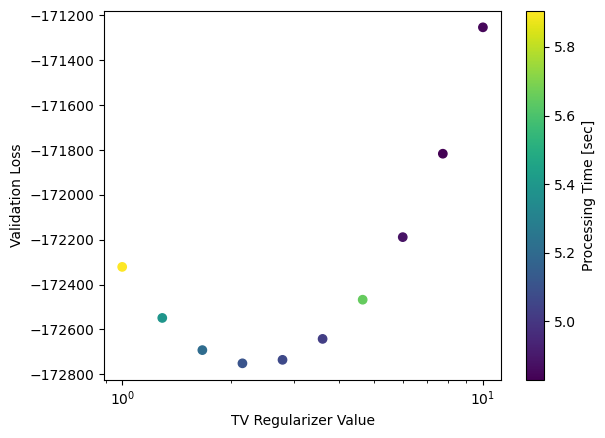

In [41]:
plt.figure()
plt.scatter(reg_arr,np.array(vld_sol_lst),c=time_lst)
plt.xscale('log')
plt.xlabel('TV Regularizer Value')
plt.ylabel('Validation Loss')
plt.colorbar(label='Processing Time [sec]')
print(f"total fista processing time: {np.sum(time_lst)} seconds")

In [42]:
fwd_mod_sol = fwd_model_lst[0](**x_sol_lst[sol_idx])
fwd_mod_arr = fwd_mod_sol['y_mean_est'].detach().cpu().numpy()

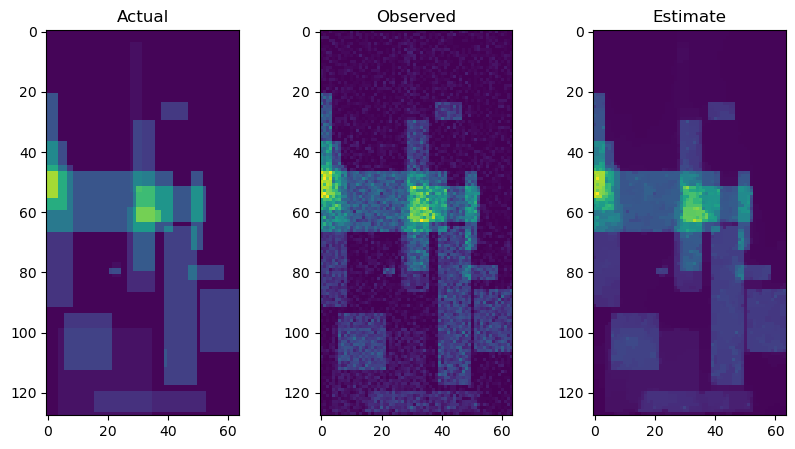

In [43]:
fig,ax = plt.subplots(1,3,figsize=(10,5))
im = ax[2].imshow(fwd_mod_arr)
ax[2].set_title("Estimate")
clim = im.get_clim()

im = ax[0].imshow(alpha_arr)
ax[0].set_title("Actual")
im.set_clim(clim)

im = ax[1].imshow(y_obs_fit)
ax[1].set_title("Observed")
im.set_clim(clim)

Text(0, 0.5, 'counts')

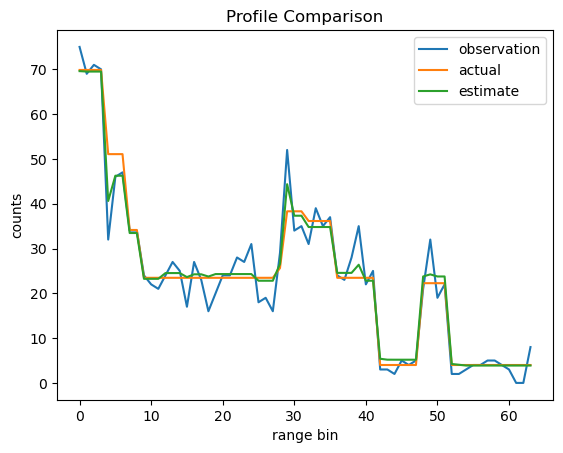

In [45]:
cross_idx = 50
plt.figure()
plt.title('Profile Comparison')
plt.plot(y_obs_dct_lst[0]['counts'].cpu().detach().numpy()[cross_idx,:],label='observation')
plt.plot(alpha_arr[cross_idx,:],label='actual')
plt.plot(fwd_mod_arr[cross_idx,:],label='estimate')
plt.legend()
plt.xlabel('range bin')
plt.ylabel('counts')

# Multi-variable Spiral with Scalar

### Create data to denoise
Generate a scene of data similar to a 2-channel lidar with a 20:80 beamsplitter in the receiver. The beamsplitter is represented by $\rho$ = 0.2. Can we also estimate $\rho$?

$\alpha_1 = \beta\rho$

$\alpha_2 = \beta(1-\rho)$

and the observations are 

$y_1 \sim Poisson(\alpha_1)$

$y_2 \sim Poisson(\alpha_2)$

In [230]:
rho_nom = .12
rec_count = 80
ch_count = 2
beta_max = 30
beta_bg = 4

x_axis = np.linspace(-10,10,64)
y_axis = np.linspace(-10,10,128)
x_ax_mesh,y_ax_mesh = np.meshgrid(x_axis,y_axis)

# normal distribution
rec_x_position_arr = 5*(np.random.randn(rec_count))
rec_y_position_arr = 5*(np.random.randn(rec_count))
rec_x_arr = np.random.randn(rec_count)*5
rec_y_arr = np.random.randn(rec_count)*5
beta_rec_arr = beta_max*np.random.rand(rec_count)
rho_rec_arr = np.ones(beta_rec_arr.shape) * rho_nom

alpha_arr_lst = []
for idx in range(ch_count):
    if idx == 0:
        alpha_arr_lst.append(np.zeros((y_axis.size,x_axis.size))+0.5*beta_bg*rho_nom)
    elif idx == 1:
        alpha_arr_lst.append(np.zeros((y_axis.size,x_axis.size))+0.5*beta_bg*(1-rho_nom))

for idx in range(rec_count):
    rec_idx = np.where((y_ax_mesh >= rec_y_position_arr[idx]-rec_y_arr[idx]/2) & (y_ax_mesh <= rec_y_position_arr[idx]+rec_y_arr[idx]/2) & \
             (x_ax_mesh >= rec_x_position_arr[idx]-rec_x_arr[idx]/2) & (x_ax_mesh <= rec_x_position_arr[idx]+rec_x_arr[idx]/2))
    
    alpha_arr_lst[0][rec_idx]+=beta_rec_arr[idx]*rho_rec_arr[idx]
    alpha_arr_lst[1][rec_idx]+=0.5*beta_rec_arr[idx]*(1-rho_rec_arr[idx])


In [231]:
# Actual values for both
x_act = {
    'beta':alpha_arr_lst[0]+alpha_arr_lst[1],
    'rho':alpha_arr_lst[0]/(alpha_arr_lst[1]+alpha_arr_lst[0])
}

In [232]:
y_obs_fit_lst = []
y_obs_val_lst = []
# create fit and validation data for the scene
for ch_idx, alpha_arr in enumerate(alpha_arr_lst):
    y_obs_fit_lst.append(np.random.poisson(alpha_arr))
    y_obs_val_lst.append(np.random.poisson(alpha_arr))

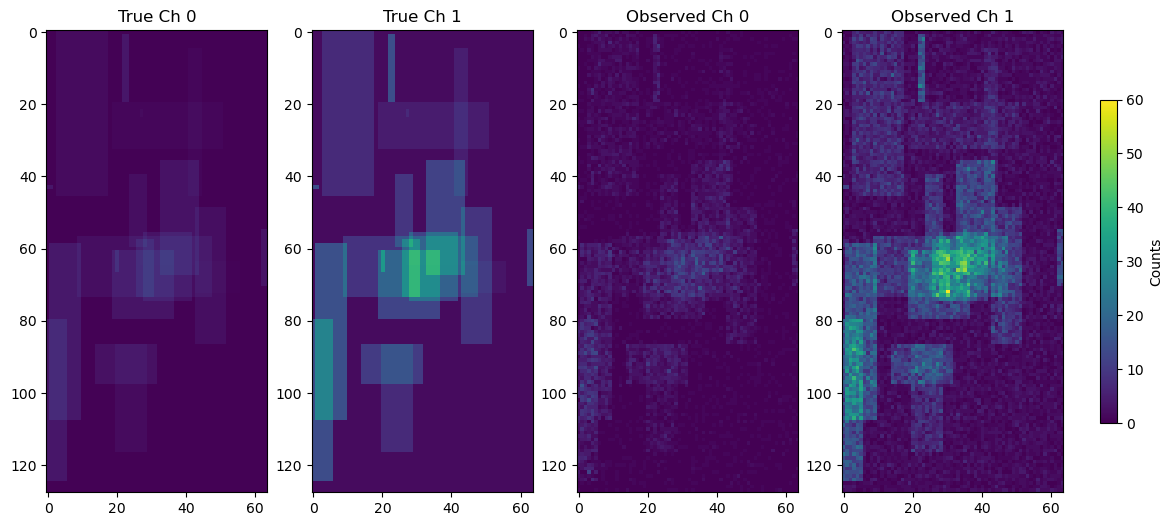

In [233]:
all_data = alpha_arr_lst + y_obs_fit_lst
global_vmin = min(np.nanmin(arr) for arr in all_data)
global_vmax = max(np.nanmax(arr) for arr in all_data)

fig, ax = plt.subplots(1, 4, figsize=(16, 6)) 


ax[0].imshow(alpha_arr_lst[0], aspect='auto', vmin=global_vmin, vmax=global_vmax)
ax[0].set_title("True Ch 0")

ax[1].imshow(alpha_arr_lst[1], aspect='auto', vmin=global_vmin, vmax=global_vmax)
ax[1].set_title("True Ch 1")

ax[2].imshow(y_obs_fit_lst[0], aspect='auto', vmin=global_vmin, vmax=global_vmax)
ax[2].set_title("Observed Ch 0")

# Saving the last handle to feed into the colorbar function
im3 = ax[3].imshow(y_obs_fit_lst[1], aspect='auto', vmin=global_vmin, vmax=global_vmax)
ax[3].set_title("Observed Ch 1")

cbar = fig.colorbar(im3, ax=ax.tolist(), orientation='vertical', pad=0.03, shrink=0.7)
cbar.set_label('Counts')

### Setup Spiral with two variables (single regularizer instance)

In [267]:
fista_ver_str = 'cuda-fista'  # 'cuda-fista', 'jit-fista'

In [268]:
def ch0_pois_fwd_model(**x):
    """
    forward model for parallel polarization channel
    
    expects x['beta'] - backscatter
            x['rho'] - split ratio
    returns 
            fwd_mod['y_mean_est']
    """
    fwd_mod = {
        'y_mean_est':torch.exp(x['beta'])*torch.exp(x['rho']) # Parameterize rho with exp to guarantee positive
    }
    return fwd_mod

def ch1_pois_fwd_model(**x):
    """
    forward model for perpendicular polarization channel
    
    expects x['beta'] - backscatter
            x['rho'] - split ratio
    returns 
            fwd_mod['y_mean_est']
    """
    fwd_mod = {
        'y_mean_est':torch.exp(x['beta'])*(1-torch.exp(x['rho'])) # Parameterize rho with exp to guarantee positive
    }
    return fwd_mod

In [269]:
fwd_model_lst = [
    ch0_pois_fwd_model,
    ch1_pois_fwd_model,
]

y_fit_dct_lst = []
y_val_dct_lst = []

for idx, y_fit in enumerate(y_obs_fit_lst):
    y_fit_dct_lst.append({'counts':y_fit})
    y_val_dct_lst.append({'counts':y_obs_val_lst[idx]})

In [270]:
# create spiral optimization object
spiral_opt = spiral.multiSpiral_autograd(device,dtype)
spiral_opt.set_fista_version(fista_ver_str)
spiral_opt.set_fwd_model_lst(fwd_model_lst)
spiral_opt.set_y_fit_lst(y_fit_dct_lst)
spiral_opt.set_y_val_lst(y_val_dct_lst)
spiral_opt.set_noise_model(['poisson','poisson'])

In [271]:
# check for alignment between observations and the noise model inputs
pass_test_bool, out_text, = spiral_opt.check_noise_model_inputs()
print(f"Check passed: {pass_test_bool}\n")
print(out_text)

Check passed: True

fit data is does not have a dictionary entry for optional input channel_mask in channel 0
validation data is does not have a dictionary entry for optional input channel_mask in channel 0
fit data is does not have a dictionary entry for optional input channel_weight in channel 0
validation data is does not have a dictionary entry for optional input channel_weight in channel 0
fit data is does not have a dictionary entry for optional input channel_mask in channel 1
validation data is does not have a dictionary entry for optional input channel_mask in channel 1
fit data is does not have a dictionary entry for optional input channel_weight in channel 1
validation data is does not have a dictionary entry for optional input channel_weight in channel 1



In [272]:
sparsa_subprob_config_dct = {
    'beta':{
        'alpha_min':1e4,
        'alpha_max':1e20,
        'alpha':1,
    },
    # As a scalar, these don't matter as much in theory
    'rho':{
        'alpha_min':1e4,
        'alpha_max':1e20,
        'alpha':1,
    }
    }

In [273]:
# set the initial conditions
x0 = {
    'beta':np.zeros(y_obs_fit_lst[0].shape)+np.log(10),
    'rho':np.zeros([1]*len(y_obs_fit_lst[0].shape))+np.log(0.1),
}

Run a single 1-off case

In [274]:
spiral_opt.set_estimate_lst(['beta','rho'])

# this is where the subproblems for each variable get created, so there needs to be an entry for each
spiral_opt.add_sparsa_config(sparsa_subprob_config_dct)
spiral_opt.set_initial_conditions(x0)
spiral_opt.set_tv_penalties({'beta':1e0,'rho':1e1})  # this must happen after the subproblem is defined
spiral_opt.verbose = True

In [266]:
#%%time
spiral_opt.solve()

'Exceeded maximum of 100 iterations'

In [243]:
x_sol = spiral_opt.get_x()
vld_loss = spiral_opt.valid_loss()  # this is used for TV regularization optimization

In [244]:
print(f"Validation Loss: {vld_loss}")

Validation Loss: -68124.48423233822


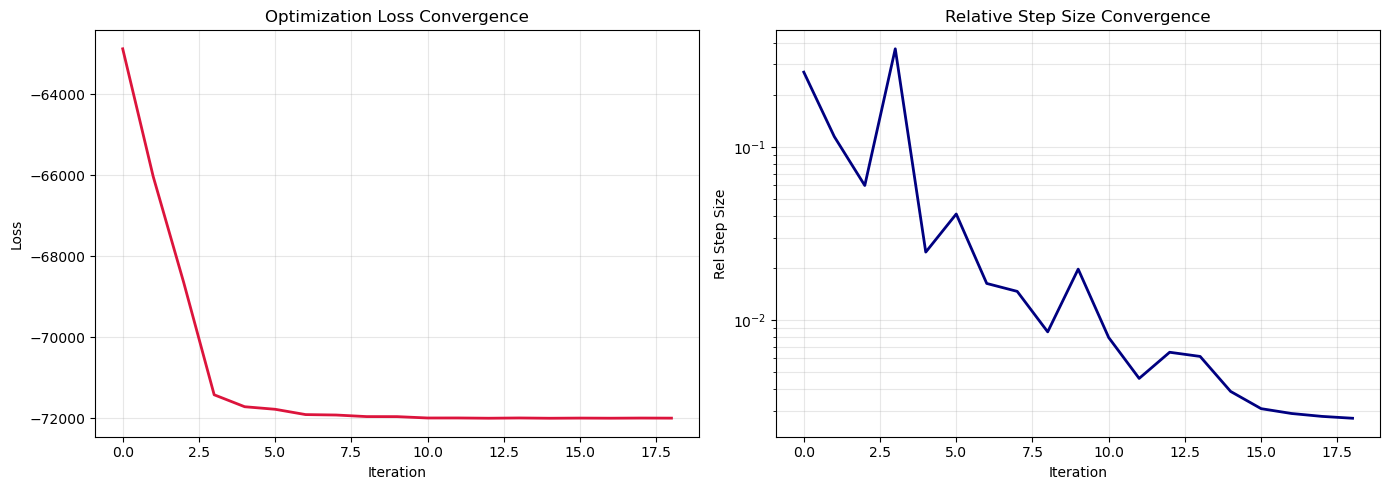

In [245]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(spiral_opt.loss_lst, color='crimson', lw=2)
ax[0].set_title("Optimization Loss Convergence")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.3)

ax[1].plot(spiral_opt.step_size_lst, color='navy', lw=2)
ax[1].set_yscale('log')
ax[1].set_title("Relative Step Size Convergence")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Rel Step Size")
ax[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()

In [246]:
# import copy
# x_act_test = copy.deepcopy(x_act)
# x_act_test['beta'] = x_act_test['beta']


True rho: 0.12
Estimated rho:  0.187



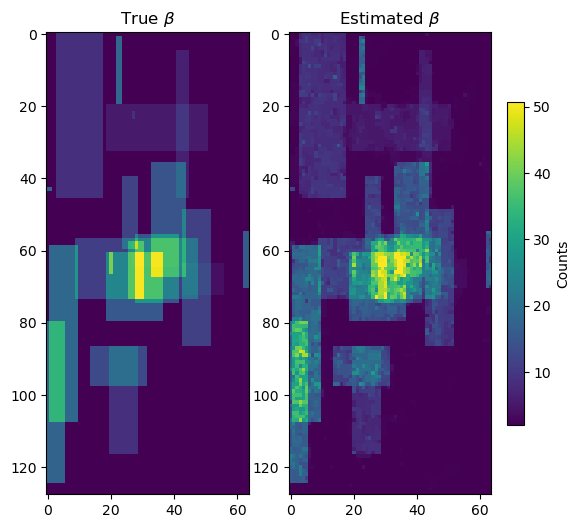

In [247]:
beta_fnc = np.exp
rho_fnc = np.exp
global_vmin = np.nanmin(x_act['beta'])
global_vmax = np.nanmax(x_act['beta'])

fig, ax = plt.subplots(1, 2, figsize=(7, 6)) 

ax[0].imshow(x_act['beta'], aspect='auto', vmin=global_vmin, vmax=global_vmax)
ax[0].set_title(r"True $\beta$")

beta_est = beta_fnc(x_sol['beta'])
im1=ax[1].imshow(beta_est, aspect='auto', vmin=global_vmin, vmax=global_vmax)
ax[1].set_title(r"Estimated $\beta$")

cbar = fig.colorbar(im1, ax=ax.tolist(), orientation='vertical', pad=0.03, shrink=0.7)
cbar.set_label('Counts')

print(f'\nTrue rho: {rho_nom}')
print(f'Estimated rho: {rho_fnc(x_sol['rho'][0,0]): .3f}\n')

plot forward model comparison

In [248]:
fwd_model_dct_lst = []
for idx, model in enumerate(spiral_opt.fwd_model_lst):
    y_est = model(**spiral_opt.x)
    fwd_dct = {}
    for var in y_est:
        fwd_dct[var] = y_est[var].detach().cpu()
    fwd_model_dct_lst.append(fwd_dct)

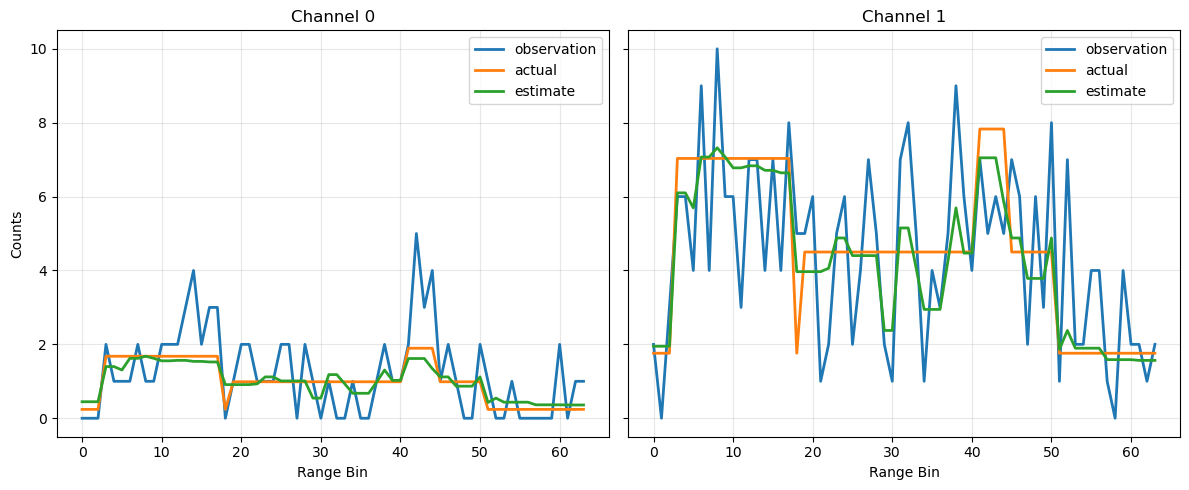

In [249]:
obs_var = 'counts'
fwd_mod_var = 'y_mean_est'
time_idx = 20
n_channels = len(fwd_model_dct_lst)

fig, ax = plt.subplots(1, n_channels, figsize=(6 * n_channels, 5), sharey=True)

if n_channels == 1:
    ax = [ax]
else:
    ax = ax.flatten()

for idx, fwd_mod in enumerate(fwd_model_dct_lst):
    ax[idx].plot(y_fit_dct_lst[idx][obs_var][time_idx,:], label='observation', lw=2.)
    ax[idx].plot(alpha_arr_lst[idx][time_idx,:], label='actual', lw=2)
    ax[idx].plot(fwd_mod[fwd_mod_var][time_idx,:], label='estimate', lw=2.)

    ax[idx].set_title(f"Channel {idx}")
    ax[idx].set_xlabel("Range Bin")
    ax[idx].legend()
    ax[idx].grid(True, alpha=0.3)
    
    if idx == 0:
        ax[idx].set_ylabel("Counts")

plt.tight_layout()

### Full regularizer optimization
Using the same forward model and observations from the previous single regularizer instance, we now expand the processing to optimize the total variation regularization.  In this case we only need to search in $\beta$. Otherwise, if the second var was nota scalar, we employ a simple grid search to locate the best regularizer solution.

In [250]:
tv_reg_dct = {
    'rho':np.array([0.0]),
    'beta':np.logspace(0,0.7,8),
}

In [251]:
# create regularizer grid
tv_lst = []
for var in tv_reg_dct:
    tv_lst.append(tv_reg_dct[var])

tv_mesh_tup = np.meshgrid(*tv_lst)

grid_count = tv_mesh_tup[0].size

In [252]:
# create spiral optimization object
spiral_opt = spiral.multiSpiral_autograd(device,dtype)
spiral_opt.set_fista_version(fista_ver_str)
spiral_opt.set_fwd_model_lst(fwd_model_lst)
spiral_opt.set_y_fit_lst(y_fit_dct_lst)
spiral_opt.set_y_val_lst(y_val_dct_lst)
spiral_opt.set_noise_model(['poisson','poisson'])

In [253]:
# check for alignment between observations and the noise model inputs
pass_test_bool, out_text, = spiral_opt.check_noise_model_inputs()
print(f"check passed: {pass_test_bool}")
print(out_text)

check passed: True
fit data is does not have a dictionary entry for optional input channel_mask in channel 0
validation data is does not have a dictionary entry for optional input channel_mask in channel 0
fit data is does not have a dictionary entry for optional input channel_weight in channel 0
validation data is does not have a dictionary entry for optional input channel_weight in channel 0
fit data is does not have a dictionary entry for optional input channel_mask in channel 1
validation data is does not have a dictionary entry for optional input channel_mask in channel 1
fit data is does not have a dictionary entry for optional input channel_weight in channel 1
validation data is does not have a dictionary entry for optional input channel_weight in channel 1



In [254]:
sparsa_subprob_config_dct = {
    'beta':{
        'alpha_min':1e4,
        'alpha_max':1e20,
        'alpha':1,
    },
    'rho':{
        'alpha_min':1e5,
        'alpha_max':1e20,
        'alpha':1e5,
    }
    }

In [255]:
# set the initial conditions
x0 = {
    'beta':np.zeros(y_obs_fit_lst[0].shape)+np.log(10),
    'rho':np.zeros([1]*len(y_obs_fit_lst[0].shape))+np.log(0.5),
}

In [256]:
spiral_opt.set_estimate_lst(['beta','rho'])

# this is where the subproblems for each variable get created, so there needs to be an entry for each
spiral_opt.add_sparsa_config(sparsa_subprob_config_dct)
spiral_opt.set_initial_conditions(x0)
# spiral_opt.set_tv_penalties({'beta':1e0,'d':1e1})  # this must happen after the subproblem is defined
spiral_opt.verbose = False

In [257]:
x_sol_lst = []
vld_loss_lst = []
opt_time_lst = []
for idx in range(grid_count):
    tv_dct = {}
    for var_idx, var in enumerate(tv_reg_dct):
        tv_dct[var] = tv_mesh_tup[var_idx].flatten()[idx]
        print(var+f": {tv_mesh_tup[var_idx].flatten()[idx]}")
    spiral_opt.set_tv_penalties(tv_dct)  # this must happen after the subproblem is defined
    
    # reinitialize
    # spiral_opt.set_alpha(1.0)
    spiral_opt.set_initial_conditions(x0)
    
    # optimize
    spiral_opt.solve()

    # store result
    x_sol = spiral_opt.get_x()
    x_sol_lst.append(x_sol)
    vld_loss = spiral_opt.valid_loss()  # this is used for TV regularization optimization
    vld_loss_lst.append(vld_loss)
    opt_time_lst.append(spiral_opt.stop_time - spiral_opt.start_time)
    print(f"validation loss: {vld_loss}")
    print(f"optimization time: {opt_time_lst[-1]} seconds")
    print()

print(f"Total Optimization Time: {np.sum(opt_time_lst)} seconds")

rho: 0.0
beta: 1.0
validation loss: -68124.05003137833
optimization time: 10.557363748550415 seconds

rho: 0.0
beta: 1.258925411794167
validation loss: -68209.5732946483
optimization time: 14.37396502494812 seconds

rho: 0.0
beta: 1.5848931924611134
validation loss: -68256.08767185328
optimization time: 14.239697456359863 seconds

rho: 0.0
beta: 1.9952623149688795
validation loss: -68239.17014254251
optimization time: 13.872624158859253 seconds

rho: 0.0
beta: 2.5118864315095797
validation loss: -68149.45647582246
optimization time: 13.05841851234436 seconds

rho: 0.0
beta: 3.162277660168379
validation loss: -67979.84928010454
optimization time: 22.75603222846985 seconds

rho: 0.0
beta: 3.9810717055349722
validation loss: -67731.24198634164
optimization time: 24.073457717895508 seconds

rho: 0.0
beta: 5.011872336272722
validation loss: -67383.09309739836
optimization time: 30.10534644126892 seconds

Total Optimization Time: 143.0369052886963 seconds


In [258]:
sol_idx = np.argmin(vld_loss_lst)
x_sol = x_sol_lst[sol_idx]

total fista processing time: 143.0369052886963 seconds


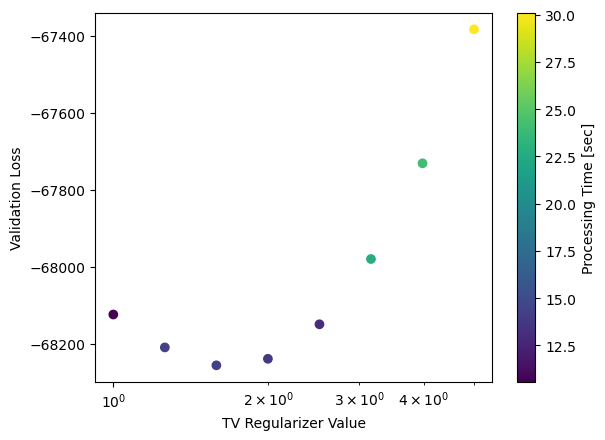

In [259]:
plt.figure()
plt.scatter(tv_reg_dct['beta'],np.array(vld_loss_lst),c=opt_time_lst)
plt.xscale('log')
plt.xlabel('TV Regularizer Value')
plt.ylabel('Validation Loss')
plt.colorbar(label='Processing Time [sec]')
print(f"total fista processing time: {np.sum(opt_time_lst)} seconds")

Direct calculation of $\beta$ and $\rho$ (standard method)

In [260]:
obs_var = 'counts'
a1_est = y_fit_dct_lst[0][obs_var]
a2_est = y_fit_dct_lst[1][obs_var]

beta_dir_est = a1_est + a2_est
rho_dir_est = np.nanmean(a1_est/(a1_est+a2_est))
x_dir_est = {'beta':beta_dir_est,'rho':rho_dir_est}

/glade/derecho/scratch/bgarby/tmp/ipykernel_13258/35897949.py:6: RuntimeWarning: invalid value encountered in divide
  rho_dir_est = np.nanmean(a1_est/(a1_est+a2_est))



True rho: 0.12
Estimated rho:  0.186
Direct estimated rho:  0.156



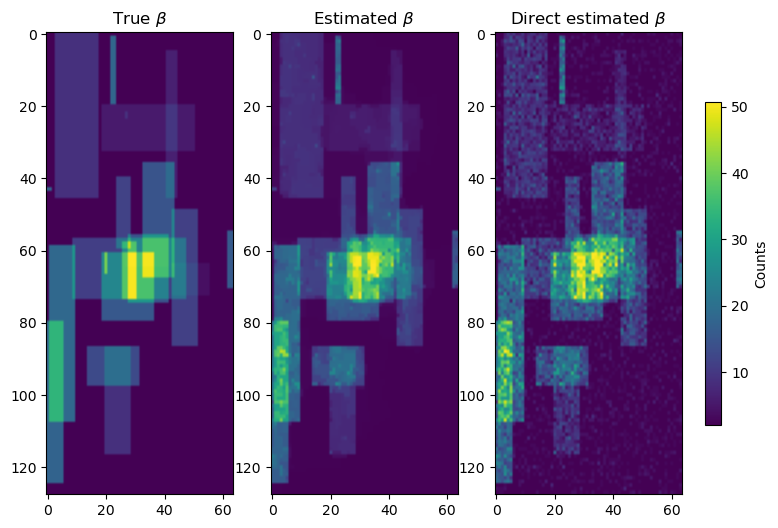

In [265]:
beta_fnc = np.exp
rho_fnc = np.exp
global_vmin = np.nanmin(x_act['beta'])
global_vmax = np.nanmax(x_act['beta'])

fig, ax = plt.subplots(1, 3, figsize=(10, 6)) 

ax[0].imshow(x_act['beta'], aspect='auto', vmin=global_vmin, vmax=global_vmax)
ax[0].set_title(r"True $\beta$")

beta_est = beta_fnc(x_sol['beta'])
ax[1].imshow(beta_est, aspect='auto', vmin=global_vmin, vmax=global_vmax)
ax[1].set_title(r"Estimated $\beta$")

im2=ax[2].imshow(beta_dir_est, aspect='auto', vmin=global_vmin, vmax=global_vmax)
ax[2].set_title(r"Direct estimated $\beta$")

cbar = fig.colorbar(im2, ax=ax.tolist(), orientation='vertical', pad=0.03, shrink=0.7)
cbar.set_label('Counts')

print(f'\nTrue rho: {rho_nom}')
print(f'Estimated rho: {rho_fnc(x_sol['rho'][0,0]): .3f}')
print(f'Direct estimated rho: {rho_dir_est: .3f}\n')

In [262]:
fwd_model_dct_lst = []

x_sol_tnsr = {}

for var in x_sol:
    x_sol_tnsr[var] = spiral_opt.to_tensor(x_sol[var])

for idx, model in enumerate(spiral_opt.fwd_model_lst):
    y_est = model(**x_sol_tnsr)
    fwd_dct = {}
    for var in y_est:
        fwd_dct[var] = y_est[var].detach().cpu()
    fwd_model_dct_lst.append(fwd_dct)

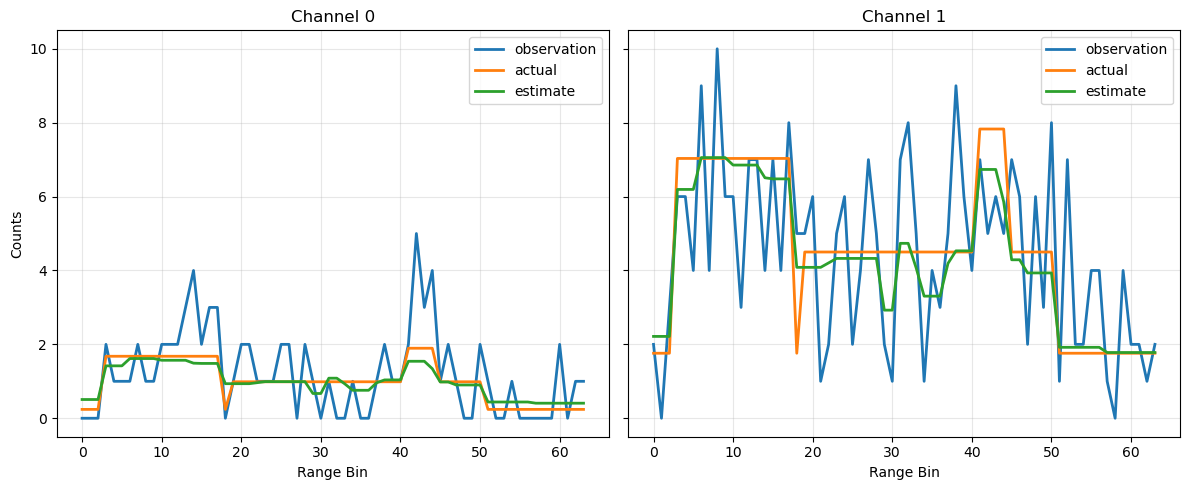

In [263]:
obs_var = 'counts'
fwd_mod_var = 'y_mean_est'
time_idx = 20
n_channels = len(fwd_model_dct_lst)

fig, ax = plt.subplots(1, n_channels, figsize=(6 * n_channels, 5), sharey=True)

if n_channels == 1:
    ax = [ax]
else:
    ax = ax.flatten()

for idx, fwd_mod in enumerate(fwd_model_dct_lst):
    ax[idx].plot(y_fit_dct_lst[idx][obs_var][time_idx,:], label='observation', lw=2.)
    ax[idx].plot(alpha_arr_lst[idx][time_idx,:], label='actual', lw=2)
    ax[idx].plot(fwd_mod[fwd_mod_var][time_idx,:], label='estimate', lw=2.)
    
    ax[idx].set_title(f"Channel {idx}")
    ax[idx].set_xlabel("Range Bin")
    ax[idx].legend()
    ax[idx].grid(True, alpha=0.3)
    
    if idx == 0:
        ax[idx].set_ylabel("Counts")

plt.tight_layout()